# <span style="color:red; font-size:30px"> Final Project Group 9 </span>

<font size = "5">

**By: Chad Himes (2774762), Aarin Singh (2758062), Sammy Paradise (2737621)**




<font size = "3">

This project aims to explore which countries produce the best soccer (or football) players and to see if those patterns are similar or different to the men's and women's data we have. (Maybe we will dive into if these are the same teams throughout the years and how some of the ost popular teams Argentina, Brazil, France, Spain have chnaged over the years). The data that we are using if from the videogame FIFA and their player overall rankings as a proxy for real-world preformance. This is relevant because being able to determine where the best players are produced from can help drive insight into where scouts should be recruiting players for their teams. 


Maybe

This project explores which countries produce the highest-quality soccer (football) players using FIFA 22 player ratings as a proxy for real-world performance. Specifically, we compare player quality across both men’s and women’s datasets to determine whether similar nations dominate in each. This is relevant because understanding where top players originate from can provide insight into global talent development and inform scouting strategies for professional teams. 

Our analysis finds that a small group of countries consistently rank highly in terms of average player rating, though differences emerge between the men’s and women’s datasets. In particular, we observe variation in both the depth of talent and the distribution of player ratings across countries.

<font size = "4">

Data Description:

<font size = "3">

Below, we imported the Pandas, Matplotlib.pyplot, Numpy, and warning datasets. The Pandas and Numpy librarys are used to help clean and analyze the dataset, Matplotlib.pyplot allows us to make simple graphs visualizing the data we are exploring, and the warnings library allows us to hide any errors for a cleaner final product. In the code chunck, each row is a seperate data frame, the first dataset is the male 2022 data set with 19,239 players, while second is the female player dataset that only consist of the national teams so there is only 391 players. This is important to note since it shows how male-centric and the underrepresentation thta FIFA was in 2022 by having the game revolve mainly around the male soccer/football leagues.

Maybe 

We use data from the FIFA 22 video game, which contains information on professional soccer players and their overall ratings. Two datasets are used in this analysis: one for male players and one for female players. Each row in the dataset represents an individual player, and key variables include player name, overall rating, and nationality.

The male dataset contains 19,239 players from club teams around the world, while the female dataset includes 391 players representing national teams. This difference in dataset size is important, as it may affect comparisons between the two groups. In particular, the women’s dataset reflects only top national team players, while the men’s dataset includes a much broader pool of talent.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings

In [ ]:
warnings.filterwarnings("ignore")

# Male Datasets
m_22 = pd.read_csv("2-FIFA/players_22.csv")

# Female Datsets
f_22 = pd.read_csv("2-FIFA/female_players_22.csv")

In [3]:
print(m_22.shape)
print(f_22.shape)

(19239, 110)
(391, 110)


In [4]:
print("In the FIFA 22 dataset, there are" ,len(m_22), "male players and there are", len(f_22), "female players.")

In the FIFA 22 dataset, there are 19239 male players and there are 391 female players.


To simplify the analysis, we cleaned each dataset by reducing the 100+ columns to a smaller set of columns. Specifically, we retain the player ID, player name, overall rating, and nationality. These variables allow us to evaluate player quality and aggregate statistics at the country level.

In [5]:
# Cleaning Data by selecting the cols that we want to analyze and making threshold 

cleaned_m22 = m_22[["sofifa_id", "long_name", "overall",  "nationality_name"]]
cleaned_f22 = f_22[["sofifa_id", "long_name", "overall", "nationality_name"]]

<font size = "4">

Aggregating Statstics and Merging

<font size = "3">

We then wanted to run statistics on the nationalities and then merge those results onto the main datasets, in order to make graphs and do some analysis on them.
To do this, we grouped by "nationality_name" and set the as_index argument to False in order to keep the nations as a col so we can pull the top and bottom countries later.
The statistics we collected was average overall and the num of players from each country.

To evaluate player quality by country, we grouped the data by nationality (setting the as_index parameter to false to retain the "nationality_name" col) and compute two key statistics: the average overall rating and the number of players from each country. 

After looking at the male dataset, we decided to apply a minimum threshold of 150 players per country to avoid bias from smaller countries with only a few high-rated players. Without this threshold, countries with very few players appeared overly strong. The women’s dataset does not require a threshold, as each country is represented by a fixed number of players.

In [6]:
m22_countrystats = cleaned_m22.groupby("nationality_name", as_index= False).agg( 
    avg_overall = ("overall", "mean"), 
    num_players = ("overall", "count")).round(2) 


m22_countrystats.head()

,nationality_name,avg_overall,num_players
0,Afghanistan,64.00,1
1,Albania,66.93,46
2,Algeria,70.65,51
3,Andorra,64.00,1
4,Angola,67.35,17


<font size = "3">

We then realized that the countries that came to the top were small countries with a fewer amount of good players rather than countries that produce a lot of good players. Therefore we decieded to set a 150 minimum player threshold that a country must meet in order to be ranked.

In [7]:
male_count_threshold = 150

# Filtering only countries and ranking above the threshold

filtered_m22_countrystats = cleaned_m22.groupby("nationality_name", as_index= False).agg(
    avg_overall = ("overall", "mean"),
    num_players = ("overall", "count")
).query("num_players >= @male_count_threshold").round(2).sort_values("avg_overall", ascending = False)

filtered_m22_countrystats.head()

,nationality_name,avg_overall,num_players
20,Brazil,70.85,897
80,Italy,69.98,338
124,Portugal,69.73,373
140,Spain,69.56,1086
37,Croatia,69.08,154


In [8]:
# Adding the ranks to a new col

m_ranks = []
for i in range(len(filtered_m22_countrystats)):
    m_ranks = m_ranks + [i + 1]

filtered_m22_countrystats["country_rank"] = m_ranks

<font size = "3">

We then used pd.merge to add the "avg_overall" and "country_rank" cols to the cleaned dataframe by using a left merge on "nationality_name"

In [9]:
final_m22_df = pd.merge(cleaned_m22, filtered_m22_countrystats[["nationality_name", "avg_overall", "country_rank"]], how = "left", on = "nationality_name")

In [10]:
# Repeated Same Process for Female 2022
# No threshold needed since all countries have exactly 23 players

f22_countrystats = cleaned_f22.groupby("nationality_name", as_index= False).agg(
    avg_overall = ("overall", "mean"),
    num_players = ("overall", "count")
).sort_values("avg_overall", ascending = False)

f_ranks = []

for i in range(len(f22_countrystats)):
    f_ranks = f_ranks + [i + 1]

f22_countrystats["country_rank"] = f_ranks

final_f_df = pd.merge(cleaned_f22, f22_countrystats[["nationality_name","avg_overall", "country_rank"]], how = "left", on = "nationality_name")

<font size = "4">

Graphing and Plotting

The following distributions show clear differences between the highest- and lowest-ranked countries. Top-ranked countries tend to have a greater distribution of players with a variety of high and low overall ratings, indicating a stronger, more consistent talent pool. In contrast, lower-ranked countries have right-skewed distributions with a high concentration around lower ratings, suggesting less overall player quality.

This pattern highlights that the strongest soccer nations not only produce elite players but also maintain depth across their player base.

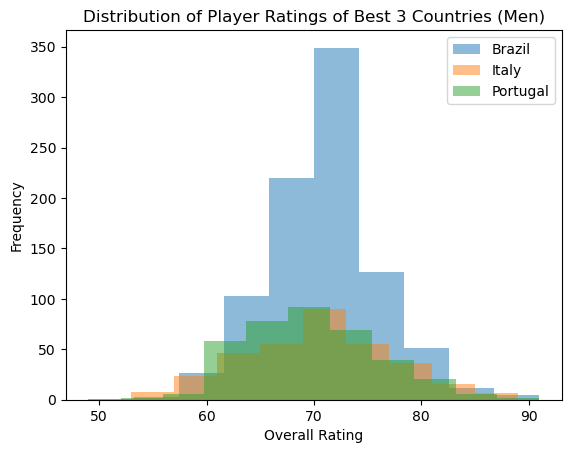

In [11]:
m22top3_countries = filtered_m22_countrystats["nationality_name"].head(3).tolist()

for country in m22top3_countries:
    df = cleaned_m22.query("nationality_name == @country")
    plt.hist(df["overall"], alpha=0.5)

plt.xlabel("Overall Rating")
plt.ylabel("Frequency")
plt.title("Distribution of Player Ratings of Best 3 Countries (Men)")
plt.legend(m22top3_countries)
plt.show()

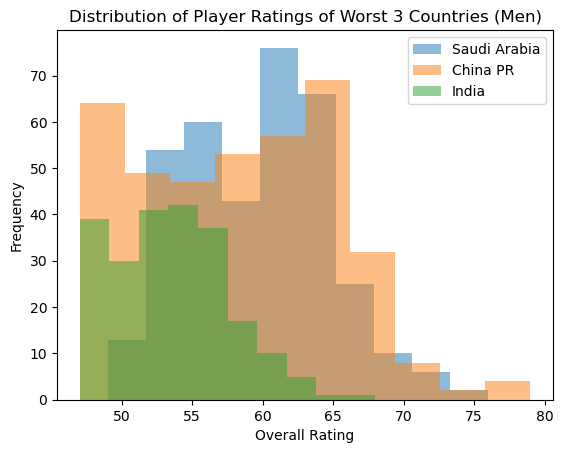

In [12]:
m22bottom3_countries = filtered_m22_countrystats["nationality_name"].tail(3).tolist()


for country in m22bottom3_countries:
    df = cleaned_m22.query("nationality_name == @country")
    plt.hist(df["overall"], alpha=0.5)

plt.xlabel("Overall Rating")
plt.ylabel("Frequency")
plt.title("Distribution of Player Ratings of Worst 3 Countries (Men)")
plt.legend(m22bottom3_countries)
plt.show()

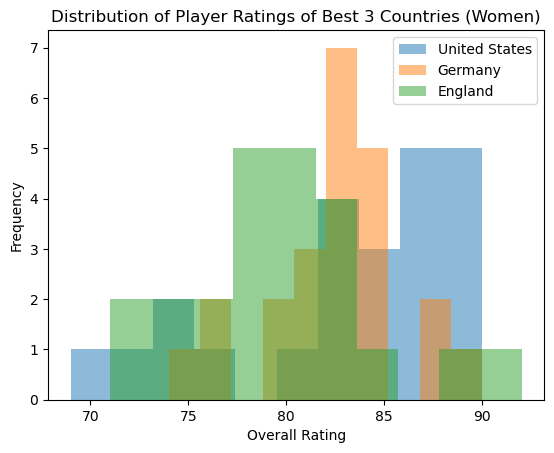

In [13]:
f22top3_countries = f22_countrystats["nationality_name"].head(3).tolist()

for country in f22top3_countries:
    df = cleaned_f22.query("nationality_name == @country")
    plt.hist(df["overall"], alpha=0.5)

plt.xlabel("Overall Rating")
plt.ylabel("Frequency")
plt.title("Distribution of Player Ratings of Best 3 Countries (Women)")
plt.legend(f22top3_countries)
plt.show()

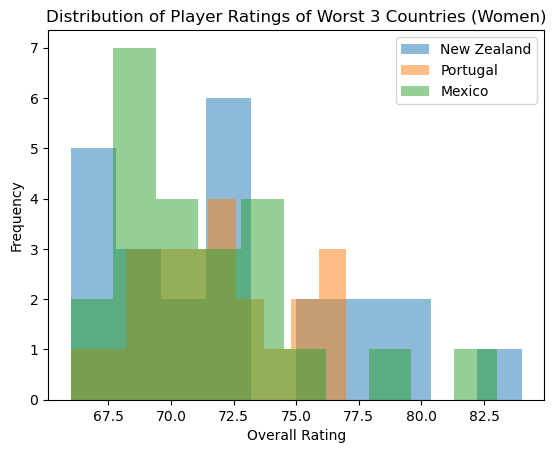

In [14]:
f22bottom3_countries = f22_countrystats["nationality_name"].tail(3).tolist()


for country in f22bottom3_countries:
    df = cleaned_f22.query("nationality_name == @country")
    plt.hist(df["overall"], alpha=0.5)

plt.xlabel("Overall Rating")
plt.ylabel("Frequency")
plt.title("Distribution of Player Ratings of Worst 3 Countries (Women)")
plt.legend(f22bottom3_countries)
plt.show()

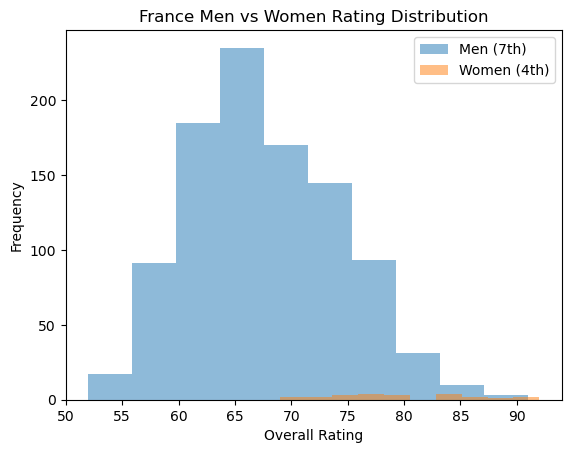

In [15]:
m22_fr = cleaned_m22.query("nationality_name == 'France'")
f22_fr= cleaned_f22.query("nationality_name == 'France'")

plt.hist(m22_fr["overall"], alpha=0.5, label="Men (7th)")
plt.hist(f22_fr["overall"], alpha=0.5, label="Women (4th)")

plt.xlabel("Overall Rating")
plt.ylabel("Frequency")
plt.title("France Men vs Women Rating Distribution")
plt.legend()
plt.show()

Make sure to talk about how these comparisons are hard to do since the gap in the player count so I might pull the top 23 players from Francee to compare maybe idk

Comparing men’s and women’s player distributions directly is challenging due to the large difference in dataset size. The men’s dataset includes thousands of players, while the women’s dataset includes only national team players. To make a more balanced comparison, we restrict the men’s data to the top 23 players (matching the number of players in the female dataset). This provides a more meaningful comparison of player quality between the two groups.

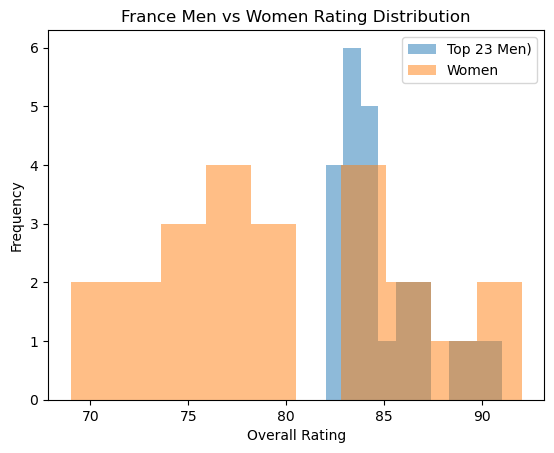

In [ ]:
# Let's see what that looks like

top23_fr_m = m22_fr.sort_values("overall", ascending= False).head(23)

plt.hist(top23_fr_m["overall"], alpha=0.5, label="Top 23 Men)")
plt.hist(f22_fr["overall"], alpha=0.5, label="Women")

plt.xlabel("Overall Rating")
plt.ylabel("Frequency")
plt.title("France Men vs Women Rating Distribution")
plt.legend()
plt.show()

These plots show how average player ratings decline as country rank decreases for both men and women. In both cases, higher-ranked countries have noticeably higher average ratings, with a gradual decline as rank increases.

However, the decline appears steeper in the men’s dataset, suggesting a wider gap between top and lower-ranked countries. In contrast, the women’s ratings appear more compressed, likely due to the smaller and more selective dataset. This indicates that while top countries perform well in both groups, the distribution of talent differs between men’s and women’s soccer.

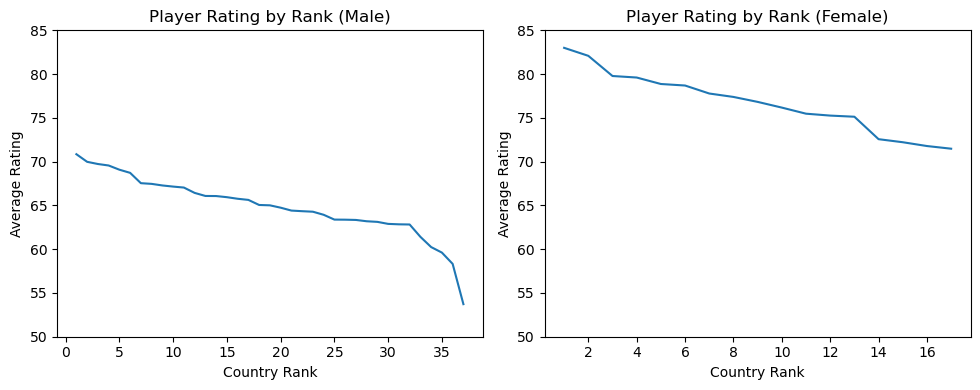

In [31]:
fig, subplt = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

subplt[0].plot(filtered_m22_countrystats["country_rank"], filtered_m22_countrystats["avg_overall"])
subplt[0].set_xlabel("Country Rank")
subplt[0].set_ylabel("Average Rating")
subplt[0].set_title("Player Rating by Rank (Male)")
subplt[0].set_ylim(50, 85)

subplt[1].plot(f22_countrystats["country_rank"], f22_countrystats["avg_overall"])
subplt[1].set_xlabel("Country Rank")
subplt[1].set_ylabel("Average Rating")
subplt[1].set_title("Player Rating by Rank (Female)")
subplt[1].set_ylim(50, 85)


plt.tight_layout()
plt.show()


<font size = "4">

Discussion

<font size = "3">

In this project, we analyzed FIFA 22 player data to determine which countries produce the highest-quality soccer players and how these patterns compare between men and women. We found that a small number of countries consistently rank highly in terms of average player ratings, indicating strong player development systems and deep talent pools.

While there is some overlap between top-performing countries in the men’s and women’s datasets, differences emerge due to the structure and size of the data. The men’s dataset includes a much larger and more diverse pool of players, leading to greater variation in ratings. In contrast, the women’s dataset is limited to national teams, resulting in more compressed rating distributions.

There are several limitations to this analysis. FIFA ratings are subjective and may not perfectly reflect real-world performance. Additionally, differences in dataset size and composition make direct comparisons between men and women more difficult. Despite these limitations, the analysis provides useful insights into global patterns of soccer talent and highlights the importance of considering both player quality and depth when evaluating countries.